<a href="https://colab.research.google.com/github/iradharia/Cornell-BTT-AI-Portfolio/blob/main/BTT_Habitat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# all of our imports
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#loading all csvs from the folder

for dirname, _, filenames in os.walk('/content/drive/MyDrive/WiDS Competition/WiDSWorldWide_GlobalDathon26'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/drive/MyDrive/WiDS Competition/WiDSWorldWide_GlobalDathon26/sample_submission.csv
/content/drive/MyDrive/WiDS Competition/WiDSWorldWide_GlobalDathon26/metaData.csv
/content/drive/MyDrive/WiDS Competition/WiDSWorldWide_GlobalDathon26/test.csv
/content/drive/MyDrive/WiDS Competition/WiDSWorldWide_GlobalDathon26/train.csv


In [ ]:
# Load the Datasets
train_csv= pd.read_csv('/content/drive/MyDrive/WiDS Competition/WiDSWorldWide_GlobalDathon26/train.csv')
test_csv=pd.read_csv('/content/drive/MyDrive/WiDS Competition/WiDSWorldWide_GlobalDathon26/test.csv')

In [ ]:
train_csv['target_72h']=((train_csv['event']==1) & (train_csv['time_to_hit_hours']<=72)).astype(int)


In [ ]:
# Check dataset shape
print(f'{train_csv.shape[0]} rows and {train_csv.shape[1]} columns in training data')
print(f'{test_csv.shape[0]} rows and {test_csv.shape[1]} columns in test data')

221 rows and 38 columns in training data
95 rows and 35 columns in test data


In [ ]:
# Check shape in table format for train
train_csv.head(10)

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event,target_72h
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0,0
5,12773599,1,0.000000,1,184.767610,0.000000,0.000000,0.000000,5.224496,0.000000,...,0.000000,0.000000,0.000000,0.000000,0,5,7,44.026384,0,0
6,13122360,1,0.000000,1,119.364203,0.000000,0.000000,0.000000,4.790522,0.000000,...,0.000000,0.000000,0.000000,0.000000,21,1,3,14.845392,1,1
7,13745272,1,0.000000,1,1388.283778,0.000000,0.000000,0.000000,7.236544,0.000000,...,0.000000,0.000000,0.000000,0.000000,16,0,6,66.767927,0,0
8,15247236,2,1.892776,0,4.493970,0.000000,0.000000,0.000000,1.703651,0.000000,...,0.106322,0.106322,0.000000,0.000000,18,5,8,39.912630,0,0
9,15743535,1,0.000000,1,5.218524,0.000000,0.000000,0.000000,1.827533,0.000000,...,0.000000,0.000000,0.000000,0.000000,17,2,7,54.638109,1,1


In [ ]:
# Check shape in table format for test
test_csv.head(10)

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
0,10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
1,13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
2,13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
3,16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
4,17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,...,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7
5,17445696,1,0.000000,1,252.500921,0.000000,0.00000,0.000000,5.535367,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,3,7
6,17599982,1,0.000000,1,3.780153,0.000000,0.00000,0.000000,1.564473,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,3,9
7,18750374,1,0.000000,1,4175.739883,0.000000,0.00000,0.000000,8.337286,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,16,0,5
8,21365245,1,0.000000,1,999.043196,0.000000,0.00000,0.000000,6.907798,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,5,5,7
9,23634840,1,0.000000,1,26.685444,0.000000,0.00000,0.000000,3.320907,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,1,3,8


In [ ]:
#print missing values (there are none)
def print_missing_values_info(df):
    missing_values=df.isnull().sum()
    missing_values=missing_values[missing_values>0]
    if len(missing_values)>0:
        print("⚠️ Columns with missing values:")
        print(missing_values)
    else:
        print(f"✅ No missing values found")

print_missing_values_info(test_csv)

✅ No missing values found


In [ ]:
#check duplicates
def print_duplicate_rows_info(df):
    duplicate_rows=df.duplicated().sum()
    if duplicate_rows>0:
        print(f"⚠️ Number of duplicate rows: {duplicate_rows}")
    else:
        print("✅ No duplicate rows found")

print_duplicate_rows_info(train_csv)

✅ No duplicate rows found


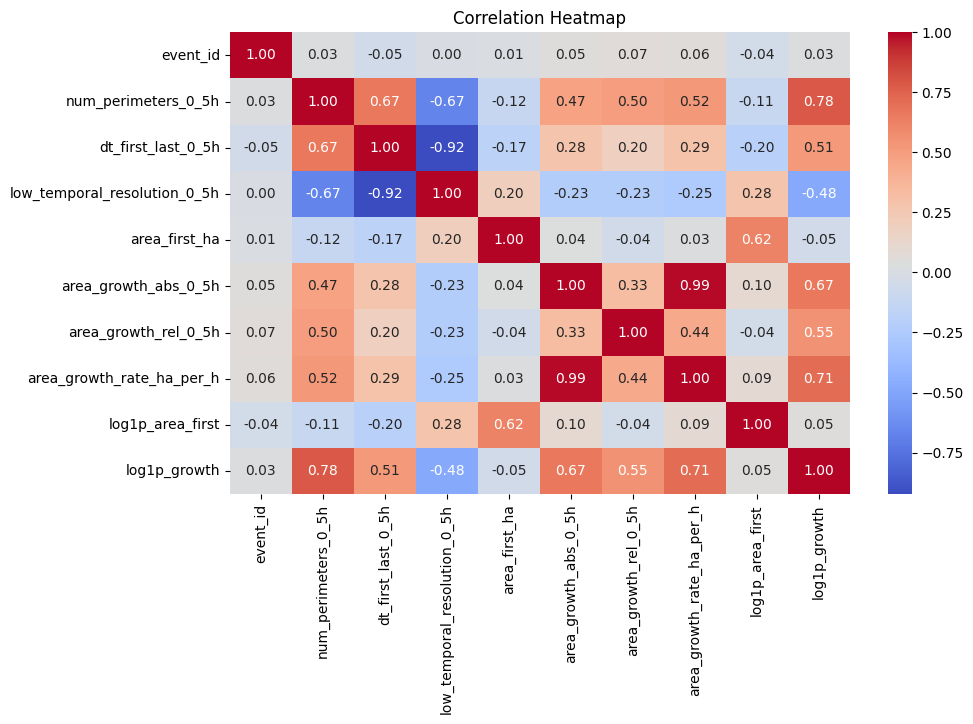

In [ ]:
#correlation map for first 10 columns
plt.figure(figsize=(10,6))
df=train_csv.columns[:10]
sns.heatmap(train_csv[df].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


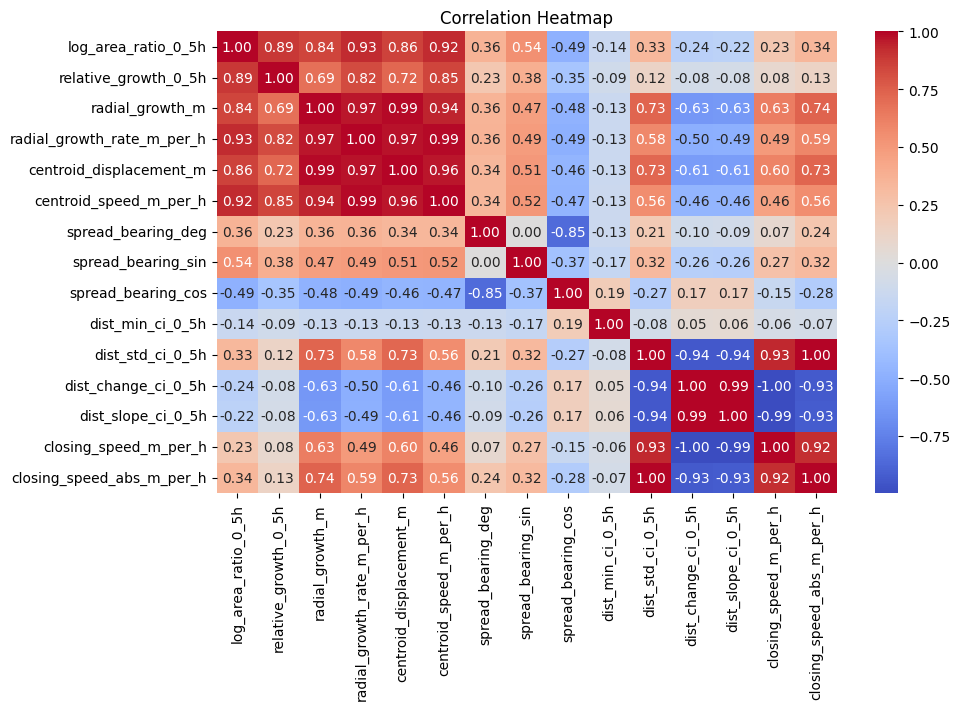

In [ ]:
#correlation map for columns 10-25
plt.figure(figsize=(10,6))
df=train_csv.columns[10:25]
sns.heatmap(train_csv[df].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

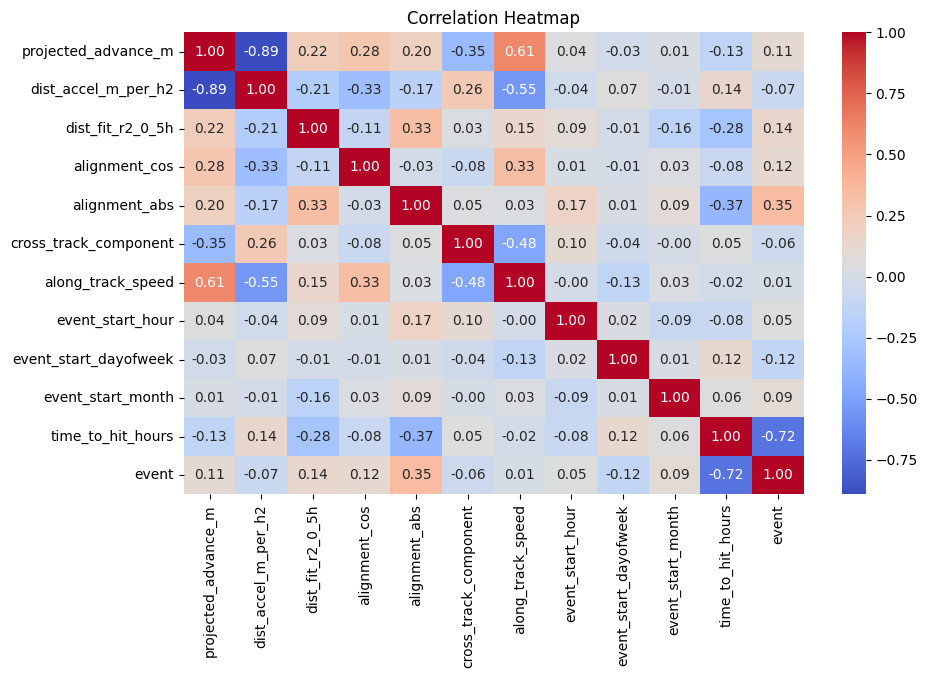

In [ ]:
plt.figure(figsize=(10,6))
df=train_csv.columns[25:37]
sns.heatmap(train_csv[df].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      221 non-null    int64  
 1   num_perimeters_0_5h           221 non-null    int64  
 2   dt_first_last_0_5h            221 non-null    float64
 3   low_temporal_resolution_0_5h  221 non-null    int64  
 4   area_first_ha                 221 non-null    float64
 5   area_growth_abs_0_5h          221 non-null    float64
 6   area_growth_rel_0_5h          221 non-null    float64
 7   area_growth_rate_ha_per_h     221 non-null    float64
 8   log1p_area_first              221 non-null    float64
 9   log1p_growth                  221 non-null    float64
 10  log_area_ratio_0_5h           221 non-null    float64
 11  relative_growth_0_5h          221 non-null    float64
 12  radial_growth_m               221 non-null    float64
 13  radia

In [ ]:
stats = train_csv.describe().T
stats['skew'] = train_csv.skew()

print("📊 Statistical Summary:")
display(stats.head(10))

📊 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max,skew
event_id,221.0,5.384397e+07,2.507456e+07,1.089246e+07,3.209326e+07,5.244094e+07,7.457274e+07,9.933973e+07,0.015167
num_perimeters_0_5h,221.0,2.063348e+00,2.578859e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.700000e+01,3.174066
dt_first_last_0_5h,221.0,9.798688e-01,1.738052e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.356107e+00,4.994457e+00,1.408768
low_temporal_resolution_0_5h,221.0,7.285068e-01,4.457395e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.034656
area_first_ha,221.0,6.191316e+02,1.447724e+03,3.752484e-02,2.521906e+01,1.101493e+02,4.850926e+02,1.194239e+04,4.721167
area_growth_abs_0_5h,221.0,2.633240e+01,1.874370e+02,-2.156175e-05,0.000000e+00,0.000000e+00,0.000000e+00,2.508041e+03,11.231250
area_growth_rel_0_5h,221.0,1.789087e-01,1.302001e+00,-1.437844e-07,0.000000e+00,0.000000e+00,0.000000e+00,1.788970e+01,11.951708
area_growth_rate_ha_per_h,221.0,6.167128e+00,4.046737e+01,-5.292846e-06,0.000000e+00,0.000000e+00,0.000000e+00,5.204430e+02,10.281604
log1p_area_first,221.0,4.683276e+00,2.083529e+00,3.683791e-02,3.266487e+00,4.710874e+00,6.186399e+00,9.387933e+00,-0.111519
log1p_growth,221.0,3.893465e-01,1.340348e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.827656e+00,3.635148


/tmp/ipython-input-3322106858.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_csv, x='target_72h', palette=['#03A9F4', '#FF5722'])


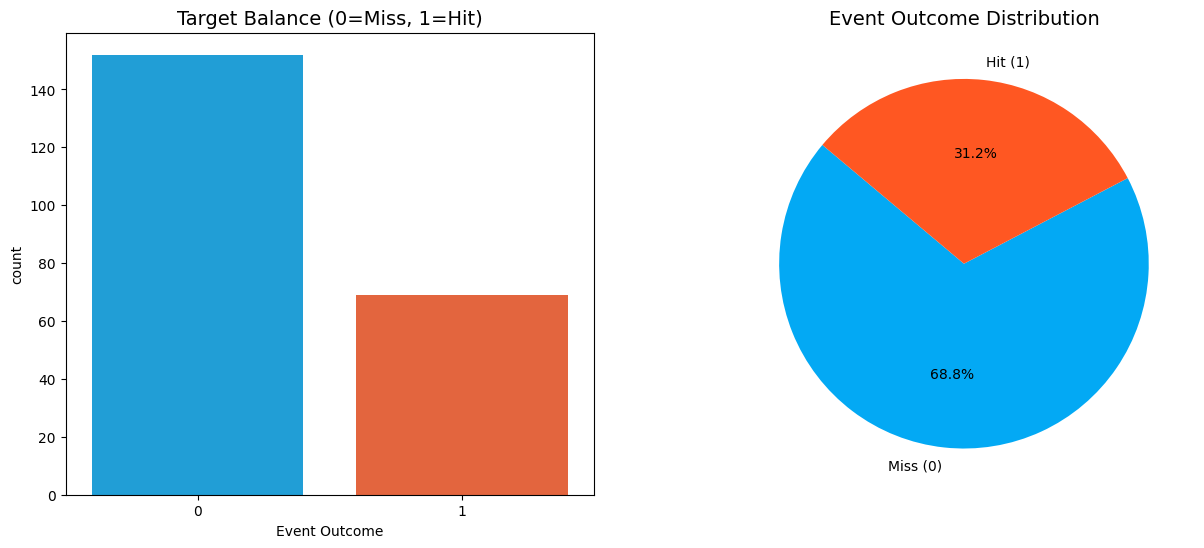

In [ ]:
# plotting the number of hits in 72 hours (event outcome is 1 when hit and 0 when miss during 72h period)
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.countplot(data=train_csv, x='target_72h', palette=['#03A9F4', '#FF5722'])
plt.title('Target Balance (0=Miss, 1=Hit)', fontsize=14)
plt.xlabel('Event Outcome')

plt.subplot(1,2,2)
plt.pie(train_csv['event'].value_counts(), labels=['Miss (0)', 'Hit (1)'], colors=['#03A9F4', '#FF5722'], autopct='%1.1f%%', startangle=140)
plt.title('Event Outcome Distribution', fontsize=14)
plt.show()

/tmp/ipython-input-348458977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_72h', y='dist_min_ci_0_5h', data=train_csv, palette='Set2')


<Axes: xlabel='target_72h', ylabel='dist_min_ci_0_5h'>

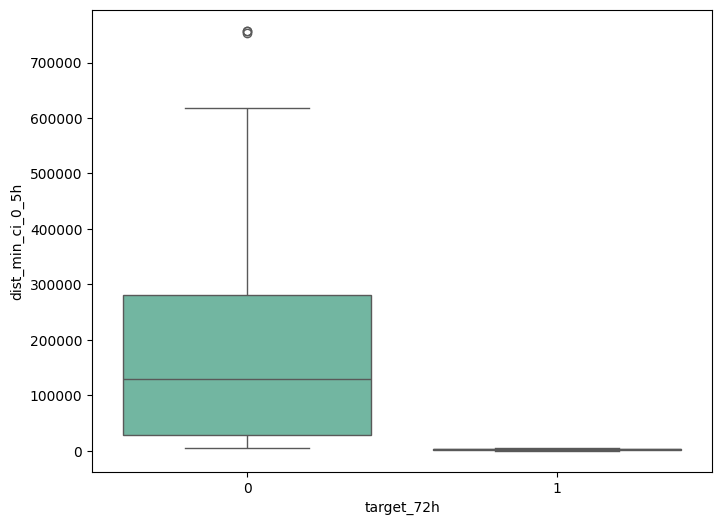

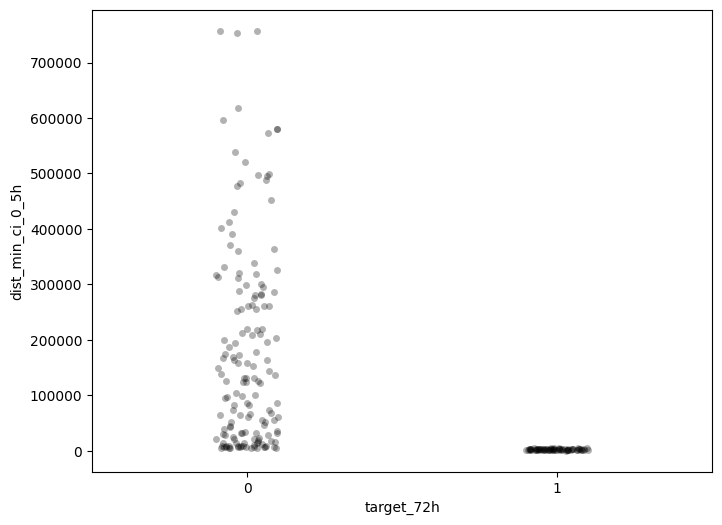

In [ ]:
#boxplot and stripplot for data visualization to see the distance threshold where fires transition from "dangerous" to "unlikely to hit."
plt.figure(figsize=(8,6))
sns.boxplot(x='target_72h', y='dist_min_ci_0_5h', data=train_csv, palette='Set2')

#stripplot for the same feature
plt.figure(figsize=(8,6))
sns.stripplot(x='target_72h', y='dist_min_ci_0_5h', data=train_csv, color='black', alpha=0.3)

/tmp/ipython-input-3499097076.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_72h', y='dist_min_ci_0_5h', data=train_csv, palette='Set2')


<Axes: xlabel='target_72h', ylabel='dist_min_ci_0_5h'>

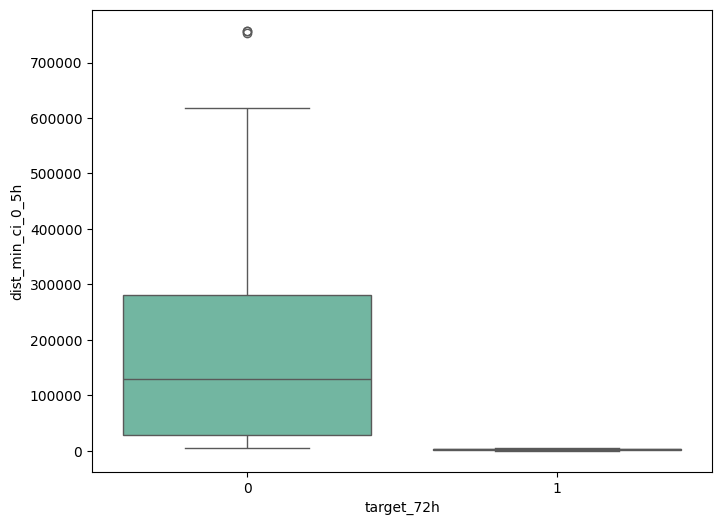

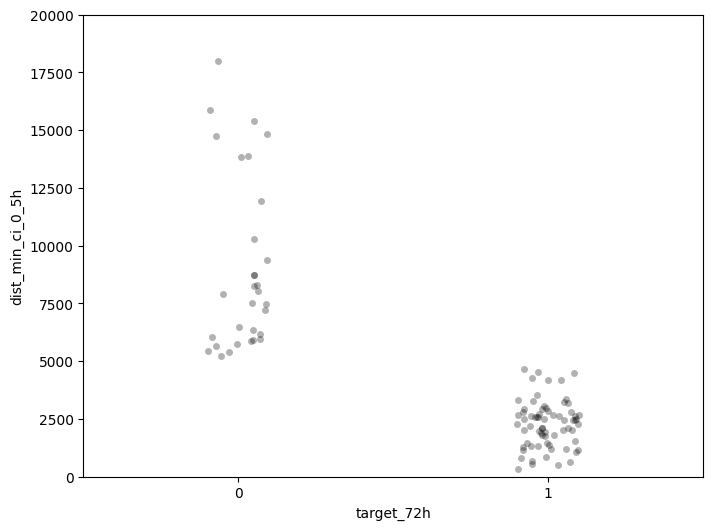

In [ ]:
#boxplot and stripplot for data visualization to see the distance threshold where fires transition from "dangerous" to "unlikely to hit."
plt.figure(figsize=(8,6))
sns.boxplot(x='target_72h', y='dist_min_ci_0_5h', data=train_csv, palette='Set2')

#stripplot for the same feature
plt.figure(figsize=(8,6))
plt.ylim(0, 20000)
sns.stripplot(x='target_72h', y='dist_min_ci_0_5h', data=train_csv, color='black', alpha=0.3)

/tmp/ipython-input-848122739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target_72h', y='area_growth_rate_ha_per_h', data=train_csv,palette='Set2')


<Axes: xlabel='target_72h', ylabel='area_growth_rate_ha_per_h'>

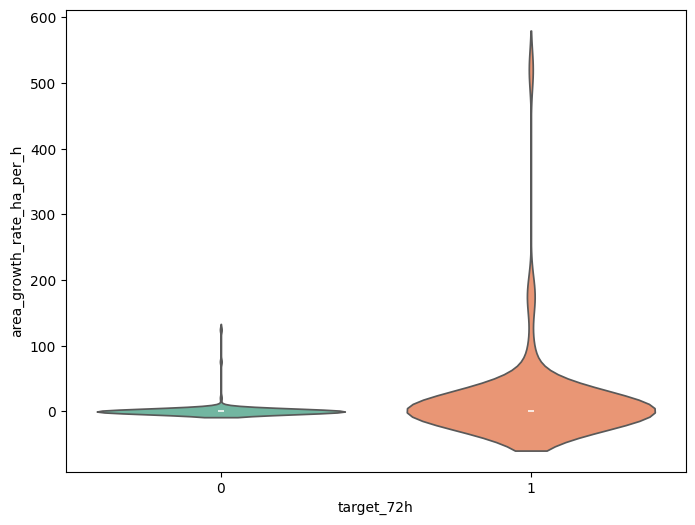

In [ ]:
#violin plot
plt.figure(figsize=(8,6))
sns.violinplot(x='target_72h', y='area_growth_rate_ha_per_h', data=train_csv,palette='Set2')

<Axes: xlabel='dist_min_ci_0_5h', ylabel='closing_speed_m_per_h'>

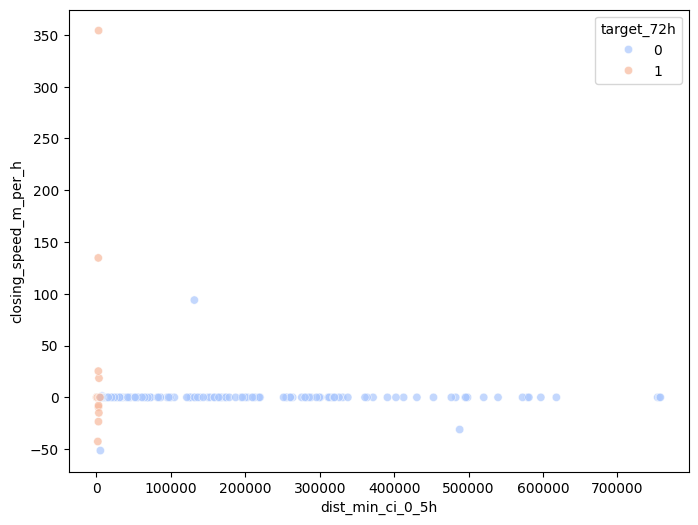

In [ ]:
#scatterplot for visualizing high risk zones
plt.figure(figsize=(8,6))
sns.scatterplot(x='dist_min_ci_0_5h', y='closing_speed_m_per_h', hue='target_72h', data=train_csv, palette='coolwarm', alpha=0.7)

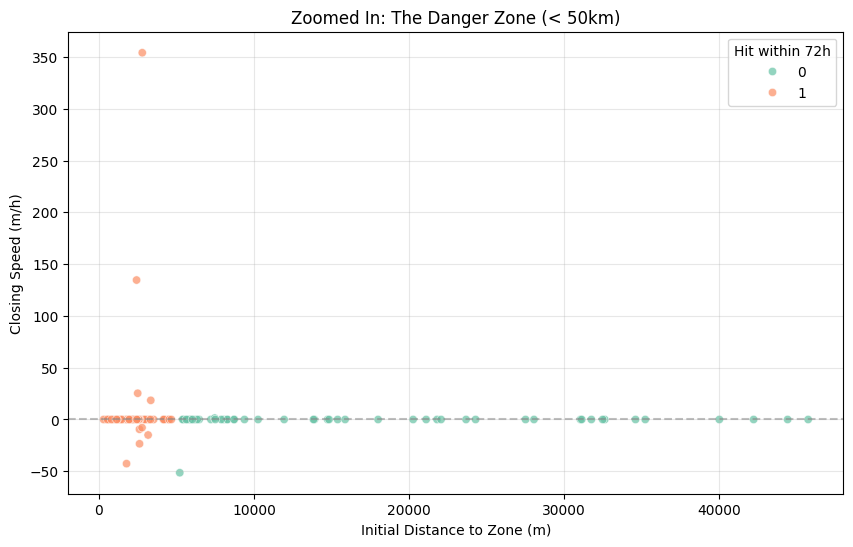

In [ ]:
# danger zone zoomed in scatter plot
# 1. Filter data to focus on the 'Danger Zone' (Distance < 50,000m)
danger_zone_df = train_csv[train_csv['dist_min_ci_0_5h'] <= 50000]

# 2. Re-create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=danger_zone_df,
    x='dist_min_ci_0_5h',
    y='closing_speed_m_per_h',
    hue='target_72h',
    alpha=0.7,
    palette='Set2'
)

# 3. Add a horizontal line at 0 for Closing Speed
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.title('Zoomed In: The Danger Zone (< 50km)')
plt.xlabel('Initial Distance to Zone (m)')
plt.ylabel('Closing Speed (m/h)')
plt.legend(title='Hit within 72h', loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

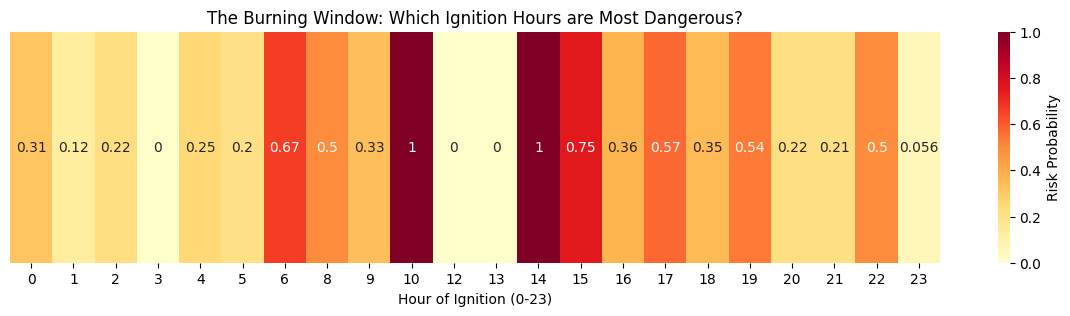

In [ ]:
# 2. Calculate the 'Hit Rate' (Probability) for each hour
# This tells us: "Of all fires that started at 2 PM, what % became hits?"
hourly_risk = train_csv.groupby('event_start_hour')['target_72h'].mean().to_frame().T

# 3. Create the Heatmap
plt.figure(figsize=(15, 3))
sns.heatmap(hourly_risk, annot=True, cmap='YlOrRd', cbar_kws={'label': 'Risk Probability'})

plt.title('The Burning Window: Which Ignition Hours are Most Dangerous?')
plt.xlabel('Hour of Ignition (0-23)')
plt.yticks([]) # Hide y-axis since it's one row
plt.show()

In [ ]:
features = [
    'dist_min_ci_0_5h', 'dist_slope_ci_0_5h', 'area_first_ha',
    'area_growth_rate_ha_per_h', 'radial_growth_rate_m_per_h',
    'closing_speed_m_per_h', 'centroid_speed_m_per_h',
    'along_track_speed', 'spread_bearing_sin', 'spread_bearing_cos',
    'alignment_cos', 'event_start_hour', 'event_start_month',
    'num_perimeters_0_5h', 'dist_fit_r2_0_5h'
]
X = train_csv[features]
y = train_csv['target_72h']

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        14

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

ROC-AUC Score: 1.0000


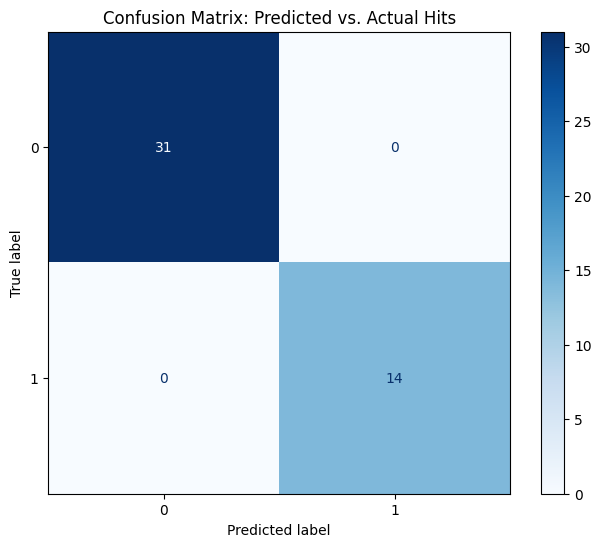

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = rf_model.predict(X_val)
y_probs = rf_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_probs):.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_val, y_val, cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs. Actual Hits')
plt.show()

In [ ]:
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances.head(5))

                Feature  Importance
0      dist_min_ci_0_5h    0.572760
2         area_first_ha    0.062204
10        alignment_cos    0.055057
11     event_start_hour    0.049493
13  num_perimeters_0_5h    0.048229


In [ ]:
print(train_csv.groupby('target_72h')['dist_min_ci_0_5h'].agg(['min', 'max', 'mean']))

                    min            max          mean
target_72h                                          
0           5215.748715  757700.487102  179832.30310
1            306.954551    4673.854411    2285.81835


creating the 4 targets

In [ ]:
horizons = [12,24,48,72]

for h in horizons:
  train_csv[f"target_{h}h"]= ((train_csv['event'] == 1) & (train_csv['time_to_hit_hours'] <= h)).astype(int)
hit_counts = train_csv[[f"target_{h}h" for h in horizons]].sum()
print("Number of hits at each horizon:", hit_counts)

Number of hits at each horizon: target_12h    49
target_24h    63
target_48h    66
target_72h    69
dtype: int64


<Axes: >

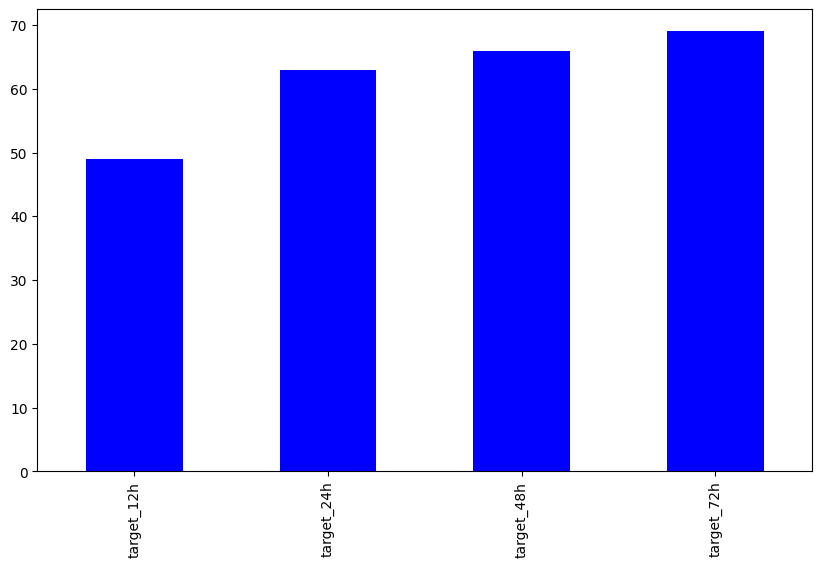

In [ ]:
plt.figure(figsize=(10,6))
hit_counts.plot(kind='bar',color='blue')

In [ ]:
from sklearn.multioutput import MultiOutputClassifier


target_cols = ['target_12h', 'target_24h', 'target_48h', 'target_72h']
y_multi = train_csv[target_cols]

X_train, X_val, y_train_multi, y_val_multi = train_test_split(
    X,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi['target_72h']
)


base_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

multi_rf = MultiOutputClassifier(base_rf)
multi_rf.fit(X_train, y_train_multi)

MultiOutputClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                       max_depth=5,
                                                       random_state=42))

In [ ]:
probs_list = multi_rf.predict_proba(X_val)
prob_results = pd.DataFrame({
    'Prob_12h': probs_list[0][:, 1],
    'Prob_24h': probs_list[1][:, 1],
    'Prob_48h': probs_list[2][:, 1],
    'Prob_72h': probs_list[3][:, 1]
})

print(prob_results.head(10))

   Prob_12h  Prob_24h  Prob_48h  Prob_72h
0  0.194466  0.201734  0.198978  0.192098
1  0.053433  0.087555  0.080486  0.108857
2  0.115325  0.095920  0.134953  0.118475
3  0.041575  0.091592  0.091016  0.089146
4  0.191843  0.168476  0.157092  0.168706
5  0.808917  0.885724  0.918580  0.919485
6  0.091713  0.129598  0.119076  0.147045
7  0.683509  0.845878  0.833759  0.842563
8  0.067752  0.109098  0.088247  0.148482
9  0.099013  0.116981  0.098382  0.144512


In [ ]:
X_test = test_csv[features]

test_probs_list = multi_rf.predict_proba(X_test)

submission1=pd.DataFrame({
    'event_id': test_csv['event_id'],
    'prob_12h': test_probs_list[0][:, 1],
    'prob_24h': test_probs_list[1][:, 1],
    'prob_48h': test_probs_list[2][:, 1],
    'prob_72h': test_probs_list[3][:, 1]
})

submission1['prob_24h'] = submission1[['prob_12h', 'prob_24h']].max(axis=1)
submission1['prob_48h'] = submission1[['prob_24h', 'prob_48h']].max(axis=1)
submission1['prob_72h'] = submission1[['prob_48h', 'prob_72h']].max(axis=1)

submission1.to_csv('submission1.csv', index=False)

print(submission1.head())

   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.125107  0.156136  0.156136  0.186097
1  13353600  0.621925  0.779119  0.792303  0.797297
2  13942327  0.089898  0.140554  0.140554  0.177759
3  16112781  0.749079  0.784425  0.810842  0.814394
4  17132808  0.417057  0.417136  0.417136  0.417136
